### Load the dataset, split features and labels, standardize features, and set random seeds.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Load dataset
csv_path = "../mobile_price.csv"
df = pd.read_csv(csv_path)

# Split features and labels
X = df.drop(columns=["price_range"])
y = df["price_range"]

feature_names = X.columns.tolist()

# Standardize all original features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

seeds = [0, 10, 42, 100, 999]

### Define a function to map cluster IDs to true labels and evaluate clustering performance.

In [2]:
def map_clusters_to_labels(y_true, y_cluster):
    """
    Map K-means cluster IDs to true labels using Hungarian algorithm.
    This is only used for evaluation after clustering.
    """
    y_true = np.array(y_true)
    y_cluster = np.array(y_cluster)

    labels = np.unique(y_true)
    clusters = np.unique(y_cluster)

    cost_matrix = np.zeros((len(clusters), len(labels)), dtype=int)

    for i, cluster in enumerate(clusters):
        for j, label in enumerate(labels):
            cost_matrix[i, j] = np.sum((y_cluster == cluster) & (y_true == label))

    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[clusters[r]] = labels[c]

    y_pred_mapped = np.array([mapping[cluster] for cluster in y_cluster])
    return y_pred_mapped


def evaluate_clustering(y_true, y_cluster):
    y_pred = map_clusters_to_labels(y_true, y_cluster)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

### Run the original K-means baseline using all standardized features.

In [3]:
original_results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)
    metrics = evaluate_clustering(y, clusters)

    metrics["Method"] = "Original K-means"
    metrics["Seed"] = seed

    original_results.append(metrics)

original_results_df = pd.DataFrame(original_results)

original_avg = original_results_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].mean()

original_results_df

c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

,Accuracy,Precision,Recall,F1-score,Method,Seed
0,0.2945,0.294042,0.2945,0.292637,Original K-means,0
1,0.2955,0.295336,0.2955,0.293648,Original K-means,10
2,0.2970,0.296623,0.2970,0.295035,Original K-means,42
3,0.2955,0.294995,0.2955,0.293510,Original K-means,100
4,0.2985,0.298367,0.2985,0.295579,Original K-means,999


### Discretize all input features into low, medium, and high categories using the 3:4:3 ratio.

In [4]:
def categorize_343(series):
    """
    Categorize a feature into low, medium, and high using the 3:4:3 ratio.
    """
    min_val = series.min()
    max_val = series.max()
    value_range = max_val - min_val

    low_threshold = min_val + 0.3 * value_range
    high_threshold = min_val + 0.7 * value_range

    def categorize_value(x):
        if x <= low_threshold:
            return "low"
        elif x <= high_threshold:
            return "medium"
        else:
            return "high"

    return series.apply(categorize_value)


categorized_X = pd.DataFrame()

for feature in feature_names:
    categorized_X[feature] = categorize_343(X[feature])

categorized_X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,low,low,medium,low,low,low,low,medium,high,low,low,low,low,medium,low,medium,high,low,low,high
1,medium,high,low,high,low,high,high,medium,medium,low,low,medium,high,medium,high,low,low,high,high,low
2,low,high,low,high,low,high,medium,high,medium,medium,low,medium,high,medium,medium,low,medium,high,high,low
3,low,high,high,low,low,low,low,high,medium,high,medium,medium,high,medium,high,medium,medium,high,low,low
4,high,high,low,low,medium,high,medium,medium,medium,low,medium,medium,medium,medium,low,low,high,high,high,low


### Convert discretized features into transaction records without using price_range.

In [5]:
transactions = []

for _, row in categorized_X.iterrows():
    transaction = []

    for feature in feature_names:
        transaction.append(f"{feature}_{row[feature]}")

    transactions.append(transaction)

transactions[:3]

[['battery_power_low',
  'blue_low',
  'clock_speed_medium',
  'dual_sim_low',
  'fc_low',
  'four_g_low',
  'int_memory_low',
  'm_dep_medium',
  'mobile_wt_high',
  'n_cores_low',
  'pc_low',
  'px_height_low',
  'px_width_low',
  'ram_medium',
  'sc_h_low',
  'sc_w_medium',
  'talk_time_high',
  'three_g_low',
  'touch_screen_low',
  'wifi_high'],
 ['battery_power_medium',
  'blue_high',
  'clock_speed_low',
  'dual_sim_high',
  'fc_low',
  'four_g_high',
  'int_memory_high',
  'm_dep_medium',
  'mobile_wt_medium',
  'n_cores_low',
  'pc_low',
  'px_height_medium',
  'px_width_high',
  'ram_medium',
  'sc_h_high',
  'sc_w_low',
  'talk_time_low',
  'three_g_high',
  'touch_screen_high',
  'wifi_low'],
 ['battery_power_low',
  'blue_high',
  'clock_speed_low',
  'dual_sim_high',
  'fc_low',
  'four_g_high',
  'int_memory_medium',
  'm_dep_high',
  'mobile_wt_medium',
  'n_cores_medium',
  'pc_low',
  'px_height_medium',
  'px_width_high',
  'ram_medium',
  'sc_h_medium',
  'sc_w_low'

### Apply FP-growth and association rule mining to discover feature-category relationships.

In [6]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(te_array, columns=te.columns_)

# Keep all frequent itemsets here, including length = 1
frequent_itemsets = fpgrowth(
    transaction_df,
    min_support=0.08,
    use_colnames=True
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))

# Generate association rules using the full frequent_itemsets
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)

# Optional: keep rules with positive or near-positive association
rules = rules[
    rules["lift"] >= 0.8
].copy()

rules = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
0,frozenset({sc_w_high}),frozenset({sc_h_high}),0.0820,0.970414,2.714445
1,frozenset({sc_h_high}),frozenset({sc_w_high}),0.0820,0.229371,2.714445
2,"frozenset({px_width_low, fc_low})","frozenset({px_height_low, pc_low})",0.0805,0.406566,2.420034
3,"frozenset({px_height_low, pc_low})","frozenset({px_width_low, fc_low})",0.0805,0.479167,2.420034
4,"frozenset({sc_h_low, pc_low})","frozenset({fc_low, sc_w_low})",0.0805,0.860963,2.342755
5,"frozenset({fc_low, sc_w_low})","frozenset({sc_h_low, pc_low})",0.0805,0.219048,2.342755
6,"frozenset({pc_low, sc_w_low})","frozenset({sc_h_low, fc_low})",0.0805,0.477745,2.341886
7,"frozenset({sc_h_low, fc_low})","frozenset({pc_low, sc_w_low})",0.0805,0.394608,2.341886
8,"frozenset({pc_low, px_width_low})","frozenset({px_height_low, fc_low})",0.0805,0.809045,2.298424
9,"frozenset({px_height_low, fc_low})","frozenset({pc_low, px_width_low})",0.0805,0.228693,2.298424


### Calculate ARM item weights based on support, confidence, and lift.

In [7]:
# Initialize item weights
all_items = transaction_df.columns.tolist()
item_scores = {item: [] for item in all_items}

for _, rule in rules.iterrows():
    rule_score = rule["support"] * rule["confidence"] * rule["lift"]

    involved_items = list(rule["antecedents"]) + list(rule["consequents"])

    for item in involved_items:
        item_scores[item].append(rule_score)

# Convert rule scores into item weights
item_weights = {}

for item in all_items:
    if len(item_scores[item]) > 0:
        item_weights[item] = 1.0 + np.mean(item_scores[item])
    else:
        item_weights[item] = 1.0

item_weights_df = pd.DataFrame({
    "item": list(item_weights.keys()),
    "ARM_weight": list(item_weights.values())
}).sort_values(
    by="ARM_weight",
    ascending=False
).reset_index(drop=True)

item_weights_df.head(20)

,item,ARM_weight
0,sc_w_high,1.133527
1,three_g_low,1.075612
2,pc_low,1.059444
3,sc_h_low,1.057271
4,four_g_high,1.056270
5,px_width_low,1.054655
6,three_g_high,1.053084
7,fc_low,1.051149
8,px_height_low,1.048878
9,sc_w_low,1.048613


### Construct and standardize the unsupervised ARM ordinal hardware score for each sample.

In [8]:
def item_level_score(item):
    if item.endswith("_low"):
        return 0
    elif item.endswith("_medium"):
        return 1
    elif item.endswith("_high"):
        return 2
    else:
        return 0


arm_scores = []

for transaction in transactions:
    score = 0.0

    for item in transaction:
        score += item_level_score(item) * item_weights.get(item, 1.0)

    arm_scores.append(score)

arm_scores = np.array(arm_scores)

# Standardize ARM score
arm_scores_scaled = StandardScaler().fit_transform(
    arm_scores.reshape(-1, 1)
)

print("ARM score shape:", arm_scores_scaled.shape)
print("ARM score min:", arm_scores.min())
print("ARM score max:", arm_scores.max())

ARM score shape: (2000, 1)
ARM score min: 4.183890153550471
ARM score max: 33.66965188474462


### Run the proposed ARM Score-only K-means method using the ARM score as the clustering input.

In [9]:
arm_score_only_results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )
    
    clusters = kmeans.fit_predict(arm_scores_scaled)
    metrics = evaluate_clustering(y, clusters)
    
    metrics["Method"] = "ARM Score-only K-means"
    metrics["Seed"] = seed
    
    arm_score_only_results.append(metrics)

arm_score_only_results_df = pd.DataFrame(arm_score_only_results)

arm_score_only_avg = arm_score_only_results_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].mean()

arm_score_only_results_df

c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

,Accuracy,Precision,Recall,F1-score,Method,Seed
0,0.321,0.348827,0.321,0.321717,ARM Score-only K-means,0
1,0.321,0.348827,0.321,0.321717,ARM Score-only K-means,10
2,0.321,0.348827,0.321,0.321717,ARM Score-only K-means,42
3,0.321,0.348827,0.321,0.321717,ARM Score-only K-means,100
4,0.321,0.348827,0.321,0.321717,ARM Score-only K-means,999


### Run ARM Score-only K-means with quantile-based initialization as an additional variant.

In [10]:
def get_1d_quantile_initial_centers(score_scaled, raw_score, n_clusters=4):
    quantile_group = pd.qcut(
        raw_score,
        q=n_clusters,
        labels=False,
        duplicates="drop"
    )
    
    centers = []
    
    for group in sorted(pd.Series(quantile_group).dropna().unique()):
        group_idx = np.where(quantile_group == group)[0]
        centers.append(score_scaled[group_idx].mean(axis=0))
    
    centers = np.array(centers)
    
    if centers.shape[0] != n_clusters:
        return None
    
    return centers


init_centers_score_only = get_1d_quantile_initial_centers(
    arm_scores_scaled,
    arm_scores,
    n_clusters=4
)

arm_score_quantile_results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=4,
        init=init_centers_score_only,
        n_init=1,
        random_state=seed
    )
    
    clusters = kmeans.fit_predict(arm_scores_scaled)
    metrics = evaluate_clustering(y, clusters)
    
    metrics["Method"] = "ARM Score-only Quantile-initialized K-means"
    metrics["Seed"] = seed
    
    arm_score_quantile_results.append(metrics)

arm_score_quantile_results_df = pd.DataFrame(arm_score_quantile_results)

arm_score_quantile_avg = arm_score_quantile_results_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].mean()

arm_score_quantile_results_df

c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

,Accuracy,Precision,Recall,F1-score,Method,Seed
0,0.319,0.328979,0.319,0.31854,ARM Score-only Quantile-initialized K-means,0
1,0.319,0.328979,0.319,0.31854,ARM Score-only Quantile-initialized K-means,10
2,0.319,0.328979,0.319,0.31854,ARM Score-only Quantile-initialized K-means,42
3,0.319,0.328979,0.319,0.31854,ARM Score-only Quantile-initialized K-means,100
4,0.319,0.328979,0.319,0.31854,ARM Score-only Quantile-initialized K-means,999


### Define quantile-based initial centers using the unsupervised ARM score.

In [11]:
def get_quantile_initial_centers(X_input, score, n_clusters=4):
    """
    Initialize cluster centers using quantiles of the unsupervised ARM score.
    """
    quantile_group = pd.qcut(
        score,
        q=n_clusters,
        labels=False,
        duplicates="drop"
    )

    centers = []

    for group in sorted(pd.Series(quantile_group).dropna().unique()):
        group_idx = np.where(quantile_group == group)[0]
        centers.append(X_input[group_idx].mean(axis=0))

    centers = np.array(centers)

    if centers.shape[0] != n_clusters:
        return None

    return centers

### Select the best ARM score weight using silhouette score without using label information.

In [12]:
alpha_list = [1, 2, 3, 5, 8, 10, 15, 20]

alpha_selection_results = []

for alpha in alpha_list:
    X_arm = np.concatenate(
        [X_scaled, alpha * arm_scores_scaled],
        axis=1
    )

    init_centers = get_quantile_initial_centers(
        X_arm,
        arm_scores,
        n_clusters=4
    )

    if init_centers is None:
        continue

    silhouette_scores = []

    for seed in seeds:
        kmeans = KMeans(
            n_clusters=4,
            init=init_centers,
            n_init=1,
            random_state=seed
        )

        clusters = kmeans.fit_predict(X_arm)

        sil = silhouette_score(X_arm, clusters)
        silhouette_scores.append(sil)

    alpha_selection_results.append({
        "alpha": alpha,
        "Average silhouette score": np.mean(silhouette_scores)
    })

alpha_selection_df = pd.DataFrame(alpha_selection_results).sort_values(
    by="Average silhouette score",
    ascending=False
).reset_index(drop=True)

alpha_selection_df

best_alpha = alpha_selection_df.loc[0, "alpha"]
best_alpha

c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

np.int64(20)

### Run ARM Score Quantile-initialized K-means using the selected ARM score weight.

In [13]:
X_arm_best = np.concatenate(
    [X_scaled, best_alpha * arm_scores_scaled],
    axis=1
)

init_centers = get_quantile_initial_centers(
    X_arm_best,
    arm_scores,
    n_clusters=4
)

improved_results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=4,
        init=init_centers,
        n_init=1,
        random_state=seed
    )

    clusters = kmeans.fit_predict(X_arm_best)
    metrics = evaluate_clustering(y, clusters)

    metrics["Method"] = "ARM Score Quantile-initialized K-means"
    metrics["Seed"] = seed
    metrics["alpha"] = best_alpha

    improved_results.append(metrics)

improved_results_df = pd.DataFrame(improved_results)

improved_avg = improved_results_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].mean()

improved_results_df

c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

,Accuracy,Precision,Recall,F1-score,Method,Seed,alpha
0,0.319,0.328979,0.319,0.31854,ARM Score Quantile-initialized K-means,0,20
1,0.319,0.328979,0.319,0.31854,ARM Score Quantile-initialized K-means,10,20
2,0.319,0.328979,0.319,0.31854,ARM Score Quantile-initialized K-means,42,20
3,0.319,0.328979,0.319,0.31854,ARM Score Quantile-initialized K-means,100,20
4,0.319,0.328979,0.319,0.31854,ARM Score Quantile-initialized K-means,999,20


### Compare the original K-means baseline with the proposed ARM Score-only K-means method.

In [14]:
q5_main_results = pd.DataFrame([
    {
        "Method": "Original K-means",
        "Accuracy": original_avg["Accuracy"],
        "Precision": original_avg["Precision"],
        "Recall": original_avg["Recall"],
        "F1-score": original_avg["F1-score"]
    },
    {
        "Method": "ARM Score-only K-means",
        "Accuracy": arm_score_only_avg["Accuracy"],
        "Precision": arm_score_only_avg["Precision"],
        "Recall": arm_score_only_avg["Recall"],
        "F1-score": arm_score_only_avg["F1-score"]
    }
])

q5_main_results = q5_main_results.round(4)

q5_main_results

,Method,Accuracy,Precision,Recall,F1-score
0,Original K-means,0.2962,0.2959,0.2962,0.2941
1,ARM Score-only K-means,0.3210,0.3488,0.3210,0.3217


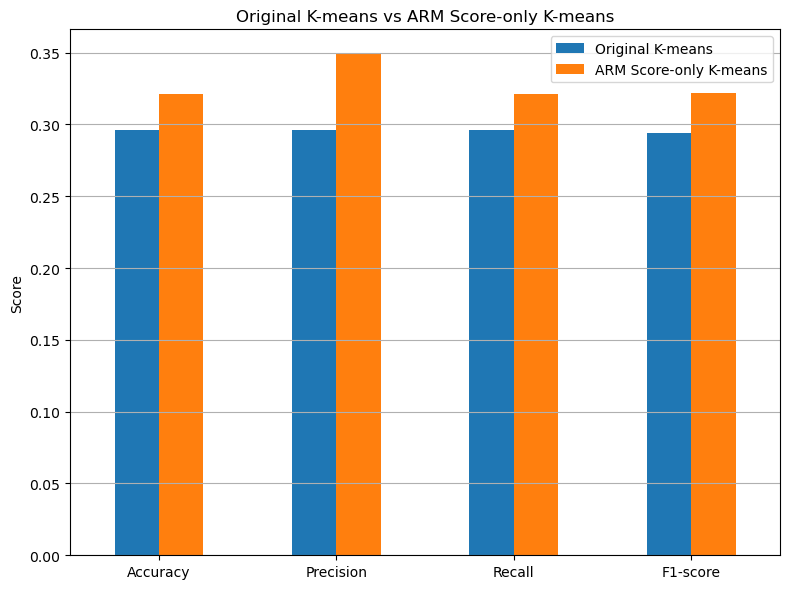

In [15]:
import matplotlib.pyplot as plt

plot_df = q5_main_results.set_index("Method")

plot_df[["Accuracy", "Precision", "Recall", "F1-score"]].T.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.ylabel("Score")
plt.title("Original K-means vs ARM Score-only K-means")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Compare all tested K-means and ARM-based K-means variants.

In [16]:
final_comparison_results = pd.DataFrame([
    {
        "Method": "Original K-means",
        "Accuracy": original_avg["Accuracy"],
        "Precision": original_avg["Precision"],
        "Recall": original_avg["Recall"],
        "F1-score": original_avg["F1-score"]
    },
    {
        "Method": "ARM Score Quantile-initialized K-means",
        "Accuracy": improved_avg["Accuracy"],
        "Precision": improved_avg["Precision"],
        "Recall": improved_avg["Recall"],
        "F1-score": improved_avg["F1-score"]
    },
    {
        "Method": "ARM Score-only K-means",
        "Accuracy": arm_score_only_avg["Accuracy"],
        "Precision": arm_score_only_avg["Precision"],
        "Recall": arm_score_only_avg["Recall"],
        "F1-score": arm_score_only_avg["F1-score"]
    },
    {
        "Method": "ARM Score-only Quantile-initialized K-means",
        "Accuracy": arm_score_quantile_avg["Accuracy"],
        "Precision": arm_score_quantile_avg["Precision"],
        "Recall": arm_score_quantile_avg["Recall"],
        "F1-score": arm_score_quantile_avg["F1-score"]
    }
])

final_comparison_results

,Method,Accuracy,Precision,Recall,F1-score
0,Original K-means,0.2962,0.295873,0.2962,0.294082
1,ARM Score Quantile-initialized K-means,0.3190,0.328979,0.3190,0.318540
2,ARM Score-only K-means,0.3210,0.348827,0.3210,0.321717
3,ARM Score-only Quantile-initialized K-means,0.3190,0.328979,0.3190,0.318540


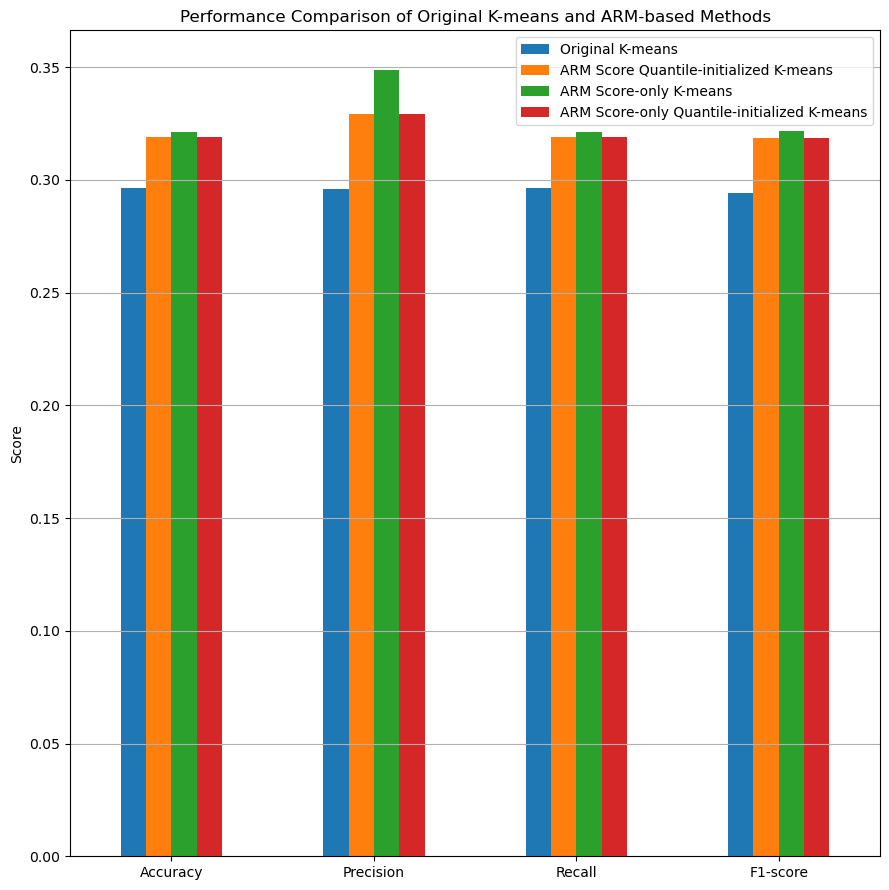

In [17]:
import matplotlib.pyplot as plt

plot_df = final_comparison_results.set_index("Method")

plot_df[["Accuracy", "Precision", "Recall", "F1-score"]].T.plot(
    kind="bar",
    figsize=(9, 9)
)

plt.ylabel("Score")
plt.title("Performance Comparison of Original K-means and ARM-based Methods")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [18]:
rules_report = rules.copy()

rules_report["antecedents"] = rules_report["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_report["consequents"] = rules_report["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_report = rules_report[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

rules_report.head(10)

,antecedents,consequents,support,confidence,lift
0,sc_w_high,sc_h_high,0.0820,0.970414,2.714445
1,sc_h_high,sc_w_high,0.0820,0.229371,2.714445
2,"fc_low, px_width_low","pc_low, px_height_low",0.0805,0.406566,2.420034
3,"pc_low, px_height_low","fc_low, px_width_low",0.0805,0.479167,2.420034
4,"pc_low, sc_h_low","fc_low, sc_w_low",0.0805,0.860963,2.342755
5,"fc_low, sc_w_low","pc_low, sc_h_low",0.0805,0.219048,2.342755
6,"pc_low, sc_w_low","fc_low, sc_h_low",0.0805,0.477745,2.341886
7,"fc_low, sc_h_low","pc_low, sc_w_low",0.0805,0.394608,2.341886
8,"pc_low, px_width_low","fc_low, px_height_low",0.0805,0.809045,2.298424
9,"fc_low, px_height_low","pc_low, px_width_low",0.0805,0.228693,2.298424
